# StackOverflow Programming Language Classifier

## Part 1 – Introduction

### Students details
- [Shai Cohen, AI Systems Developer (RAG & Backend)](https://www.linkedin.com/in/shai-cohen-9127246a/)
- [Shahar Sidon, Manual and Automated QA Engineer (ISTQB Certified)](https://www.linkedin.com/in/shahar-sidon/)

Our ID Numbers has been removed for privacy reasons in the public space.

---

### AI / LLM Prompts used

| # | Tool | Prompt Example | Purpose |
|---|------|----------------|---------|
| 1 | Cursor / Claude | Examine the kaggle dataset and give me all columns and example rows | Understand dataset structure |
| 2 | Cursor / Claude | What could be a good but simple FE to predict programming_language using multi-class classification? | Design strategies |
| 3 | Cursor / Claude | Implement this plan (long .MD prompt files) | Code generation |
| 4 | Cursor / GPT | Fix label-dependent preprocessing leakage, list other potential issues and add bonus section according to the plan (long .MD prompt files) | Refactor and finishing touches |

---

### Problem and Dataset Description

The dataset contains **95,636 StackOverflow questions** posted between 2020 and 2025, each labelled with the primary `programming_language` the question relates to (25 unique values).  
The task is **multi-class text classification**: given the question title and body, predict the programming language.  
We implement **Multinomial Naïve Bayes from scratch** over a plain bag-of-words representation, weighting the title 3× relative to the body.  
No scikit-learn learning algorithms, vectorizers, metrics, or train/test split utilities are used.

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
import math
from collections import Counter
from concurrent.futures import ThreadPoolExecutor, as_completed
from IPython.display import display, Markdown
import os
import time

### Load the dataset

In [4]:
from pathlib import Path
import pandas as pd

csv_path = Path("data/stackoverflow_combined.csv")

if csv_path.exists():
    df = pd.read_csv(
        csv_path,
        usecols=["title", "body", "programming_language"]
    )
else:
    import subprocess, sys
    import kagglehub
    from kagglehub import KaggleDatasetAdapter

    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "kagglehub[pandas-datasets]"], check=True)

    df = kagglehub.dataset_load(
        KaggleDatasetAdapter.PANDAS,
        "kutayahin/stackoverflow-programming-questions-2020-2025",
        "stackoverflow_combined.csv",
    )

    df = df[["title", "body", "programming_language"]]

df = df.dropna(subset=["title", "body", "programming_language"]).reset_index(drop=True)

print(f"Loaded {len(df):,} rows")
df.head()

Loaded 95,614 rows


,title,body,programming_language
0,AttributeError: 'NoneType' object has no attri...,I am trying to develop a tool that agent (Code...,python
1,"contextlib tries to change a ""frozen"" exception",I got a strange error in my pytest after some ...,python
2,Tkinter window shrinks after embedding Matplot...,I'm building a multi-frame Tkinter app for a s...,python
3,"CatalystAppError: {'code': 'FATAL ERROR', 'mes...",I’m working on a chatbot project using the Zoh...,python
4,Sympy : Problem with simplifying a Sympy vecto...,I am creating my own coordinate system using t...,python


### Class distribution

All classes and their row counts:
programming_language
javascript    7353
python        6488
java          5945
c++           5272
c#            5166
swift         5043
r             5014
c             4868
rust          4847
ruby          4840
sql           4821
php           4812
go            4811
kotlin        4543
scala         4526
matlab        4155
typescript    4072
perl          3853
html          3200
css           1781
bash           124
shell           47
powershell      22
dart             8
haskell          3


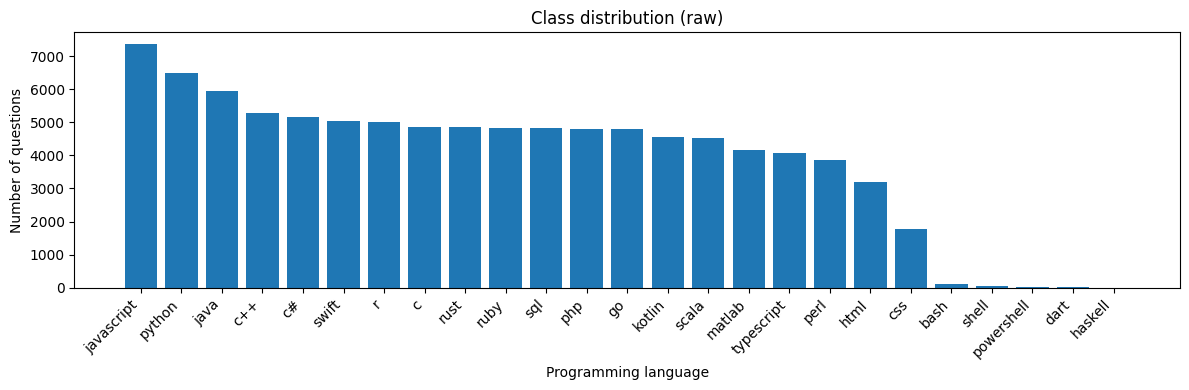

In [5]:
counts = df["programming_language"].value_counts()
print("All classes and their row counts:")
print(counts.to_string())

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(counts.index, counts.values)
ax.set_xlabel("Programming language")
ax.set_ylabel("Number of questions")
ax.set_title("Class distribution (raw)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### Merge rare classes into `other`

Any language with fewer than 500 rows is merged into a single `other` class  
to avoid near-empty classes that destabilise macro-F1.

In [6]:
MIN_CLASS_SIZE = 500

rare_langs = counts[counts < MIN_CLASS_SIZE].index.tolist()
print(f"Merging {len(rare_langs)} rare classes into 'other': {rare_langs}")

df["programming_language"] = df["programming_language"].apply(
    lambda lang: "other" if lang in rare_langs else lang
)

new_counts = df["programming_language"].value_counts()
print(f"\n{len(new_counts)} classes after merge:")
print(new_counts.to_string())

Merging 5 rare classes into 'other': ['bash', 'shell', 'powershell', 'dart', 'haskell']

21 classes after merge:
programming_language
javascript    7353
python        6488
java          5945
c++           5272
c#            5166
swift         5043
r             5014
c             4868
rust          4847
ruby          4840
sql           4821
php           4812
go            4811
kotlin        4543
scala         4526
matlab        4155
typescript    4072
perl          3853
html          3200
css           1781
other          204


### 80 / 20 train-test split

In [7]:
def stratified_split(dataframe, label_col, test_frac=0.2, seed=42):
    """Return (df_train, df_test) with proportional class representation."""
    rng = np.random.default_rng(seed)
    train_idx, test_idx = [], []

    for label, group in dataframe.groupby(label_col):
        idx = group.index.to_numpy().copy()    # .copy() required: pandas index is read-only
        rng.shuffle(idx)
        n_test = max(1, int(len(idx) * test_frac))
        test_idx.extend(idx[:n_test])
        train_idx.extend(idx[n_test:])

    df_train = dataframe.loc[train_idx].reset_index(drop=True)
    df_test  = dataframe.loc[test_idx].reset_index(drop=True)
    return df_train, df_test


df_train, df_test = stratified_split(df, "programming_language", test_frac=0.2, seed=42)

print(f"Train: {len(df_train):,} rows | Test: {len(df_test):,} rows")
print()
print("Train head:")
print(df_train[["title","programming_language"]].head().to_string())
print("\nTest head:")
print(df_test[["title","programming_language"]].head().to_string())


Train: 76,499 rows | Test: 19,115 rows

Train head:
                                                                            title programming_language
0             What are the drawbacks of implementing dequeue using procedure int?                    c
1          CS50 - Pset 2 - Substitution - Issue with Check50 Not Detecting Output                    c
2  A recursive function to reverse an integer w/o string,loops or other functions                    c
3                                                         restrict Qualifier in C                    c
4              Zephyr os mqtt tls thingsboard : mqtt_connect fails with return -2                    c

Test head:
                                                                        title programming_language
0                             Malloc sometimes fails immediately after a free                    c
1       Seg fault on string array items after tokenizing in external function                    c
2  Everything is ok b

---

## Part 2 – Feature Engineering

### Text preprocessing

For each question we:
1. Concatenate `title` repeated according to `title_weight` + `body`.
2. Lowercase.
3. Optionally remove all language names from every sample using a fixed list derived from the training labels only.
4. Tokenise with a regex that preserves multi-character tokens like `i++`, `object.objectType`, `j-=1`.
5. Optionally remove a small stopword list and always remove single-character tokens.

Preprocessing operates on `(title, body)` only - the true label is never passed in, so the same function can be used at train and test time.

In [8]:
STOPWORDS = {
    "the", "a", "an",
    "is", "it", "are", "was", "were", "be", "been", "being", "am",
    "in", "on", "at", "to", "of", "by", "from", "with",
    "about", "into", "over", "under", "between", "through",
    "this", "that", "these", "those",
    "i", "me", "my", "mine",
    "you", "your", "yours",
    "we", "our", "ours",
    "they", "their", "theirs",
    "he", "she", "his", "her", "its",
    "have", "has", "had",
    "do", "does", "did",
    "get", "gets", "got",
    "make", "makes", "made",
    "use", "uses", "using", "used",
    "try", "tries", "trying",
    "want", "wants", "wanted",
    "need", "needs", "needed",
    "know", "knows", "known",
    "find", "finds", "found",
    "seem", "seems", "seemed",
    "work", "works", "working", "worked",
    "like",
    "how", "what", "why", "when", "where", "which",
    "all", "any", "some", "many", "much", "few",
    "so", "just", "please", "thanks", "thank",
    "hi", "hello",
    "question", "example", "case",
}

# Preserves tokens such as i++, object.objectType, j-=1.
TOKEN_RE = re.compile(r"(?:\.[A-Za-z][A-Za-z0-9_+#.\-]*|[A-Za-z_][A-Za-z0-9_+=#.\-]*)")

LANGUAGE_NAMES = sorted(
    {lang.lower().strip() for lang in df_train["programming_language"].unique()},
    key=len,
    reverse=True,
)


def preprocess_text(title, body, title_weight=3, remove_language_names=False, use_stopwords=True):
    """Return tokens for one question using only title and body."""
    text = (str(title) + " ") * int(title_weight) + str(body)
    text = text.lower()

    if remove_language_names:
        for name in LANGUAGE_NAMES:
            pattern = rf"(?<!\w){re.escape(name)}(?!\w)"
            text = re.sub(pattern, " ", text)

    tokens = TOKEN_RE.findall(text)
    stopwords = STOPWORDS if use_stopwords else set()
    tokens = [t for t in tokens if len(t) > 1 and t not in stopwords]

    return tokens


print("Example of the language names that will be removed (from train labels only):")
print(LANGUAGE_NAMES)
print("Special token capture demo:", TOKEN_RE.findall("i++ object.objectType j-=1"))

Example of the language names that will be removed (from train labels only):
['typescript', 'javascript', 'matlab', 'python', 'kotlin', 'swift', 'scala', 'other', 'perl', 'java', 'ruby', 'html', 'rust', 'c++', 'sql', 'php', 'css', 'c#', 'go', 'c', 'r']
Special token capture demo: ['i++', 'object.objectType', 'j-=1']


### Demo: preprocessing on 2–3 examples

In [9]:
example_config = {
    "title_weight": 3,
    "remove_language_names": False,
    "use_stopwords": True,
}

alternative_config = {
    "title_weight": 3,
    "remove_language_names": True,
    "use_stopwords": True,
}

example_rows = []
for i in [0, 1, 2]:
    row = df_train.iloc[i]
    default_tokens = preprocess_text(row["title"], row["body"], **example_config)
    alt_tokens = preprocess_text(row["title"], row["body"], **alternative_config)
    example_rows.append({
        "row": i,
        "language": row["programming_language"],
        "title_preview": row["title"][:90],
        "tokens_keep_language_names": default_tokens[:20],
        "tokens_remove_all_language_names": alt_tokens[:20],
        "n_tokens_keep": len(default_tokens),
        "n_tokens_remove": len(alt_tokens),
    })

feature_examples_df = pd.DataFrame(example_rows)
feature_examples_df

,row,language,title_preview,tokens_keep_language_names,tokens_remove_all_language_names,n_tokens_keep,n_tokens_remove
0,0,c,What are the drawbacks of implementing dequeue...,"[drawbacks, implementing, dequeue, procedure, ...","[drawbacks, implementing, dequeue, procedure, ...",48,48
1,1,c,CS50 - Pset 2 - Substitution - Issue with Chec...,"[cs50, pset, substitution, issue, check50, not...","[cs50, pset, substitution, issue, check50, not...",104,104
2,2,c,A recursive function to reverse an integer w/o...,"[recursive, function, reverse, integer, string...","[recursive, function, reverse, integer, string...",67,62


### Vocabulary helper (training data only)

The vocabulary is always built from training data only. In cross-validation, it is rebuilt separately inside each fold using only that fold's training portion.

In [10]:
def build_vocab(token_lists, min_df=5, max_df_frac=0.5, max_size=20_000):
    """Build a token -> integer-id vocabulary from training token lists."""
    N = len(token_lists)
    max_df = int(max_df_frac * N)

    df_count = Counter()
    for tokens in token_lists:
        for tok in set(tokens):
            df_count[tok] += 1

    filtered = [
        (tok, cnt)
        for tok, cnt in df_count.items()
        if min_df <= cnt <= max_df
    ]

    filtered.sort(key=lambda x: x[1], reverse=True)
    filtered = filtered[:max_size]

    return {tok: idx for idx, (tok, _) in enumerate(filtered)}


def tokenize_dataframe(dataframe, feature_config):
    """Tokenize title/body columns with one feature-engineering configuration."""
    return [
        preprocess_text(
            row["title"],
            row["body"],
            title_weight=feature_config["title_weight"],
            remove_language_names=feature_config["remove_language_names"],
            use_stopwords=feature_config["use_stopwords"],
        )
        for _, row in dataframe.iterrows()
    ]

### Encode documents as bag-of-words count dicts

In [11]:
def encode_docs(token_lists, vocab):
    """Convert token lists to sparse count dicts using the given vocabulary.

    Returns a list of Counter objects {token_id: count}.
    Tokens not in vocab are silently ignored.
    """
    result = []
    for tokens in token_lists:
        counts = Counter()
        for tok in tokens:
            if tok in vocab:
                counts[vocab[tok]] += 1
        result.append(counts)
    return result


y_train = df_train["programming_language"].tolist()

print("Bag-of-words helpers ready.")

Bag-of-words helpers ready.


---

## Part 3 – Learning Algorithm: Multinomial Naïve Bayes

The learning algorithm is implemented from scratch with NumPy. No scikit-learn (or other library) classifier is used.

In [12]:
class MultinomialNB:
    """Multinomial Naïve Bayes classifier.

    Parameters
    ----------
    alpha : float
        Laplace (additive) smoothing parameter.  Default 1.0.
    """

    def __init__(self, alpha=1.0):
        self.alpha = alpha
        # Set after train()
        self.classes_     = None   # list of class labels in order
        self.log_prior_   = None   # 1-D numpy array, shape (n_classes,)
        self.log_cond_    = None   # 2-D numpy array, shape (n_classes, vocab_size)
        self.vocab_size_  = None

    # ------------------------------------------------------------------
    def train(self, X_counts, y):
        """Train the model.

        Parameters
        ----------
        X_counts : list of Counter  – one Counter (token_id → count) per doc
        y        : list of str      – class label for each doc
        """
        self.classes_ = sorted(set(y))
        n_classes  = len(self.classes_)
        class_to_idx = {c: i for i, c in enumerate(self.classes_)}

        # Derive vocab size from the largest token id seen + 1
        # (all ids come from the same vocab built earlier)
        max_id = 0
        for doc in X_counts:
            if doc:
                max_id = max(max_id, max(doc.keys()))
        self.vocab_size_ = max_id + 1

        N = len(y)

        # --- Log prior: log P(c) = log(N_c / N) ---
        class_doc_counts = np.zeros(n_classes, dtype=np.float64)
        for label in y:
            class_doc_counts[class_to_idx[label]] += 1
        self.log_prior_ = np.log(class_doc_counts / N)

        # --- Token counts per class: count_tc[c, t] ---
        count_tc = np.zeros((n_classes, self.vocab_size_), dtype=np.float64)
        for doc, label in zip(X_counts, y):
            c_idx = class_to_idx[label]
            for token_id, cnt in doc.items():
                count_tc[c_idx, token_id] += cnt

        # --- Smoothed log-conditional: log P(t | c) with Laplace smoothing ---
        # smoothed_count[c, t] = count_tc[c, t] + alpha
        # denominator[c]       = sum_t count_tc[c, t] + alpha * vocab_size
        smoothed = count_tc + self.alpha
        denom    = smoothed.sum(axis=1, keepdims=True)   # shape (n_classes, 1)
        self.log_cond_ = np.log(smoothed / denom)        # shape (n_classes, vocab_size)

        return self

    # ------------------------------------------------------------------
    def predict(self, X_counts):
        """Predict class labels for a list of documents.

        Parameters
        ----------
        X_counts : list of Counter  – one Counter (token_id → count) per doc

        Returns
        -------
        list of str  – predicted class label for each document
        """
        predictions = []
        for doc in X_counts:
            # Start with log-prior for each class
            scores = self.log_prior_.copy()      # shape (n_classes,)

            # Add weighted log-conditionals for every token in this document
            for token_id, cnt in doc.items():
                if token_id < self.vocab_size_:
                    scores += cnt * self.log_cond_[:, token_id]

            predictions.append(self.classes_[int(np.argmax(scores))])

        return predictions

---

## Bonus 6a/6b/6c/6g – Experiment Management

This section runs a small manual grid search with 5-fold cross-validation on `df_train` only. `df_test` is not used during cross-validation or model selection. `df_test` is used only in the final evaluation section after `best_params` are selected.

In [13]:
feature_configs = [
    {
        "feature_name": "title_x1_keep_lang_keep_stopwords",
        "title_weight": 1,
        "remove_language_names": False,
        "use_stopwords": True,
    },
    {
        "feature_name": "title_x1_remove_lang_keep_stopwords",
        "title_weight": 1,
        "remove_language_names": True,
        "use_stopwords": True,
    },
    {
        "feature_name": "title_x1_remove_lang_no_stopwords",
        "title_weight": 1,
        "remove_language_names": True,
        "use_stopwords": False,
    },
    {
        "feature_name": "title_x1_keep_lang_no_stopwords",
        "title_weight": 1,
        "remove_language_names": False,
        "use_stopwords": False,
    },
    {
        "feature_name": "title_x3_keep_lang_keep_stopwords",
        "title_weight": 3,
        "remove_language_names": False,
        "use_stopwords": True,
    },
    {
        "feature_name": "title_x3_remove_lang_keep_stopwords",
        "title_weight": 3,
        "remove_language_names": True,
        "use_stopwords": True,
    },
    {
        "feature_name": "title_x3_remove_lang_no_stopwords",
        "title_weight": 3,
        "remove_language_names": True,
        "use_stopwords": False,
    },
    {
        "feature_name": "title_x3_keep_lang_no_stopwords",
        "title_weight": 3,
        "remove_language_names": False,
        "use_stopwords": False,
    }
]

param_grid = {
    "alpha": [0.5, 1.0],
    "min_df": [2, 5],
    "max_vocab_size": [20_000],
}


def stratified_kfold_indices(y, k=5, seed=42):
    """Return stratified train/validation index splits for a label list."""
    rng = np.random.default_rng(seed)
    label_to_indices = {}
    for idx, label in enumerate(y):
        label_to_indices.setdefault(label, []).append(idx)

    folds = [[] for _ in range(k)]
    for label, indices in label_to_indices.items():
        shuffled = np.array(indices)
        rng.shuffle(shuffled)
        for fold_idx, split in enumerate(np.array_split(shuffled, k)):
            folds[fold_idx].extend(split.tolist())

    all_indices = set(range(len(y)))
    splits = []
    for fold_idx in range(k):
        val_idx = sorted(folds[fold_idx])
        train_idx = sorted(all_indices - set(val_idx))
        splits.append((train_idx, val_idx))
    return splits


def confusion_matrix(y_true, y_pred, labels):
    """Return a (C, C) confusion matrix. Row = true class, column = predicted class."""
    label_to_idx = {label: i for i, label in enumerate(labels)}
    C = len(labels)
    cm = np.zeros((C, C), dtype=np.int64)
    for true, pred in zip(y_true, y_pred):
        if true in label_to_idx and pred in label_to_idx:
            cm[label_to_idx[true], label_to_idx[pred]] += 1
    return cm


def per_class_prf(cm):
    """Compute per-class precision, recall, and F1 from a confusion matrix."""
    TP = np.diag(cm).astype(np.float64)
    FP = cm.sum(axis=0).astype(np.float64) - TP
    FN = cm.sum(axis=1).astype(np.float64) - TP

    precision_den = TP + FP
    recall_den = TP + FN

    precision = np.divide(
        TP,
        precision_den,
        out=np.zeros_like(TP, dtype=np.float64),
        where=precision_den != 0,
    )

    recall = np.divide(
        TP,
        recall_den,
        out=np.zeros_like(TP, dtype=np.float64),
        where=recall_den != 0,
    )

    f1_den = precision + recall

    f1 = np.divide(
        2 * precision * recall,
        f1_den,
        out=np.zeros_like(precision, dtype=np.float64),
        where=f1_den != 0,
    )

    return precision, recall, f1


def evaluate_predictions(y_true, y_pred, labels):
    cm = confusion_matrix(y_true, y_pred, labels)
    precision, recall, f1 = per_class_prf(cm)
    return {
        "accuracy": float(np.mean(np.array(y_true) == np.array(y_pred))),
        "macro_precision": float(precision.mean()),
        "macro_recall": float(recall.mean()),
        "macro_f1": float(f1.mean()),
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "cm": cm,
    }


def macro_f1_score(y_true, y_pred, labels):
    return evaluate_predictions(y_true, y_pred, labels)["macro_f1"]


cv_splits = stratified_kfold_indices(y_train, k=5, seed=42)
cv_result_rows = []
fold_result_rows = []
MAX_DF_FRAC = 0.5

print("Precomputing train tokens for each feature configuration...")
train_tokens_by_feature = {}
for feature_config in feature_configs:
    feature_name = feature_config["feature_name"]
    train_tokens_by_feature[feature_name] = tokenize_dataframe(df_train, feature_config)
    mean_tokens = np.mean([len(tokens) for tokens in train_tokens_by_feature[feature_name]])
    print(f"  {feature_name}: mean tokens/doc = {mean_tokens:.1f}")

for feature_config in feature_configs:
    feature_name = feature_config["feature_name"]
    full_train_tokens = train_tokens_by_feature[feature_name]

    for alpha in param_grid["alpha"]:
        for min_df in param_grid["min_df"]:
            for max_vocab_size in param_grid["max_vocab_size"]:
                fold_scores = []

                for fold_idx, (fold_train_idx, fold_val_idx) in enumerate(cv_splits, start=1):
                    fold_train_tokens = [full_train_tokens[i] for i in fold_train_idx]
                    fold_val_tokens = [full_train_tokens[i] for i in fold_val_idx]

                    fold_vocab = build_vocab(
                        fold_train_tokens,
                        min_df=min_df,
                        max_df_frac=MAX_DF_FRAC,
                        max_size=max_vocab_size,
                    )
                    X_fold_train = encode_docs(fold_train_tokens, fold_vocab)
                    X_fold_val = encode_docs(fold_val_tokens, fold_vocab)
                    y_fold_train = [y_train[i] for i in fold_train_idx]
                    y_fold_val = [y_train[i] for i in fold_val_idx]

                    fold_model = MultinomialNB(alpha=alpha)
                    fold_model.train(X_fold_train, y_fold_train)
                    y_fold_pred = fold_model.predict(X_fold_val)
                    fold_macro_f1 = macro_f1_score(y_fold_val, y_fold_pred, fold_model.classes_)
                    fold_scores.append(fold_macro_f1)

                    fold_result_rows.append({
                        "feature_name": feature_name,
                        "alpha": alpha,
                        "min_df": min_df,
                        "max_vocab_size": max_vocab_size,
                        "fold": fold_idx,
                        "macro_f1": fold_macro_f1,
                        "vocab_size": len(fold_vocab),
                    })

                cv_result_rows.append({
                    "feature_name": feature_name,
                    "title_weight": feature_config["title_weight"],
                    "remove_language_names": feature_config["remove_language_names"],
                    "use_stopwords": feature_config["use_stopwords"],
                    "alpha": alpha,
                    "min_df": min_df,
                    "max_vocab_size": max_vocab_size,
                    "mean_macro_f1": float(np.mean(fold_scores)),
                    "std_macro_f1": float(np.std(fold_scores, ddof=1)),
                })

fold_results_df = pd.DataFrame(fold_result_rows)
cv_results_df = (
    pd.DataFrame(cv_result_rows)
    .sort_values("mean_macro_f1", ascending=False)
    .reset_index(drop=True)
)

best_params = cv_results_df.iloc[0].to_dict()

print(f"Completed {len(cv_results_df)} configurations x {len(cv_splits)} folds = {len(fold_results_df)} trains")
print("Best configuration:")
display(pd.DataFrame([best_params]))

cv_results_df

Precomputing train tokens for each feature configuration...
  title_x1_keep_lang_keep_stopwords: mean tokens/doc = 73.5
  title_x1_remove_lang_keep_stopwords: mean tokens/doc = 72.2
  title_x1_remove_lang_no_stopwords: mean tokens/doc = 114.9
  title_x1_keep_lang_no_stopwords: mean tokens/doc = 116.2
  title_x3_keep_lang_keep_stopwords: mean tokens/doc = 87.7
  title_x3_remove_lang_keep_stopwords: mean tokens/doc = 85.8
  title_x3_remove_lang_no_stopwords: mean tokens/doc = 134.1
  title_x3_keep_lang_no_stopwords: mean tokens/doc = 136.0
Completed 32 configurations x 5 folds = 160 trains
Best configuration:


,feature_name,title_weight,remove_language_names,use_stopwords,alpha,min_df,max_vocab_size,mean_macro_f1,std_macro_f1
0,title_x3_keep_lang_keep_stopwords,3,False,True,0.5,5,20000,0.658906,0.005826


,feature_name,title_weight,remove_language_names,use_stopwords,alpha,min_df,max_vocab_size,mean_macro_f1,std_macro_f1
0,title_x3_keep_lang_keep_stopwords,3,False,True,0.5,5,20000,0.658906,0.005826
1,title_x3_keep_lang_keep_stopwords,3,False,True,0.5,2,20000,0.658906,0.005826
2,title_x3_keep_lang_no_stopwords,3,False,False,0.5,5,20000,0.656892,0.006457
3,title_x3_keep_lang_no_stopwords,3,False,False,0.5,2,20000,0.656892,0.006457
4,title_x3_keep_lang_keep_stopwords,3,False,True,1.0,5,20000,0.653538,0.002613
5,title_x3_keep_lang_keep_stopwords,3,False,True,1.0,2,20000,0.653538,0.002613
6,title_x3_keep_lang_no_stopwords,3,False,False,1.0,5,20000,0.651841,0.003062
7,title_x3_keep_lang_no_stopwords,3,False,False,1.0,2,20000,0.651841,0.003062
8,title_x1_keep_lang_keep_stopwords,1,False,True,0.5,2,20000,0.637705,0.004686
9,title_x1_keep_lang_keep_stopwords,1,False,True,0.5,5,20000,0.637705,0.004686


---

## Part 4 – Final Training

After selecting `best_params` by cross-validation, the final vocabulary is built from the full training set only. The test set is still held out at this point.

In [14]:
best_feature_config = next(
    config for config in feature_configs
    if config["feature_name"] == best_params["feature_name"]
)

final_train_tokens = tokenize_dataframe(df_train, best_feature_config)
final_vocab = build_vocab(
    final_train_tokens,
    min_df=int(best_params["min_df"]),
    max_df_frac=MAX_DF_FRAC,
    max_size=int(best_params["max_vocab_size"]),
)
X_train = encode_docs(final_train_tokens, final_vocab)

model = MultinomialNB(alpha=float(best_params["alpha"]))
model.train(X_train, y_train)

vocab = final_vocab
id_to_token = {idx: tok for tok, idx in vocab.items()}

training_summary_df = pd.DataFrame([{
    "feature_name": best_feature_config["feature_name"],
    "title_weight": best_feature_config["title_weight"],
    "remove_language_names": best_feature_config["remove_language_names"],
    "use_stopwords": best_feature_config["use_stopwords"],
    "alpha": model.alpha,
    "min_df": int(best_params["min_df"]),
    "max_vocab_size": int(best_params["max_vocab_size"]),
    "actual_vocab_size": len(vocab),
    "train_rows": len(X_train),
    "cv_mean_macro_f1": best_params["mean_macro_f1"],
    "cv_std_macro_f1": best_params["std_macro_f1"],
}])

training_summary_df

,feature_name,title_weight,remove_language_names,use_stopwords,alpha,min_df,max_vocab_size,actual_vocab_size,train_rows,cv_mean_macro_f1,cv_std_macro_f1
0,title_x3_keep_lang_keep_stopwords,3,False,True,0.5,5,20000,20000,76499,0.658906,0.005826


---

## Part 5 – Prediction and Evaluation

`df_test` is first preprocessed and encoded here, after model selection is complete. The same preprocessing configuration and train-built vocabulary are used for both train and test.

### Predictions for the first 5 test samples

In [15]:
y_test = df_test["programming_language"].tolist()
test_token_lists = tokenize_dataframe(df_test, best_feature_config)
X_test = encode_docs(test_token_lists, vocab)
y_pred = model.predict(X_test)

first5_preds_df = pd.DataFrame({
    "title_preview": df_test["title"].head(5).str.slice(0, 80),
    "true_label": y_test[:5],
    "predicted_label": y_pred[:5],
})
first5_preds_df["correct"] = first5_preds_df["true_label"] == first5_preds_df["predicted_label"]

first5_preds_df

,title_preview,true_label,predicted_label,correct
0,Malloc sometimes fails immediately after a free,c,c,True
1,Seg fault on string array items after tokenizi...,c,c,True
2,Everything is ok but Firebase DB PUT request r...,c,go,False
3,Using multi-char literals as enum values,c,c,True
4,Error from order of statements in a while loop,c,perl,False


### Metrics

In [16]:
labels = model.classes_
evaluation = evaluate_predictions(y_test, y_pred, labels)

cm = evaluation["cm"]
precision = evaluation["precision"]
recall = evaluation["recall"]
f1 = evaluation["f1"]
accuracy = evaluation["accuracy"]
macro_prec = evaluation["macro_precision"]
macro_rec = evaluation["macro_recall"]
macro_f1 = evaluation["macro_f1"]

metrics_df = pd.DataFrame([{
    "accuracy": accuracy,
    "macro_precision": macro_prec,
    "macro_recall": macro_rec,
    "macro_f1": macro_f1,
}]).round(4)

metrics_df

,accuracy,macro_precision,macro_recall,macro_f1
0,0.6884,0.6582,0.6656,0.6562


### Per-class report

In [17]:
support = cm.sum(axis=1)     # actual count per class in test set

report_df = pd.DataFrame({
    "class": labels,
    "precision": np.round(precision, 4),
    "recall": np.round(recall, 4),
    "f1": np.round(f1, 4),
    "support": support,
}).sort_values("f1", ascending=False).reset_index(drop=True)

report_df

,class,precision,recall,f1,support
0,swift,0.8808,0.8135,0.8458,1008
1,ruby,0.8666,0.7986,0.8312,968
2,rust,0.8186,0.7915,0.8048,969
3,scala,0.7369,0.8232,0.7777,905
4,sql,0.6789,0.8817,0.7671,964
5,r,0.7633,0.7465,0.7548,1002
6,matlab,0.6890,0.8183,0.7481,831
7,kotlin,0.7797,0.7093,0.7428,908
8,perl,0.6592,0.8364,0.7373,770
9,php,0.7109,0.7464,0.7282,962


### Confusion matrix heatmap

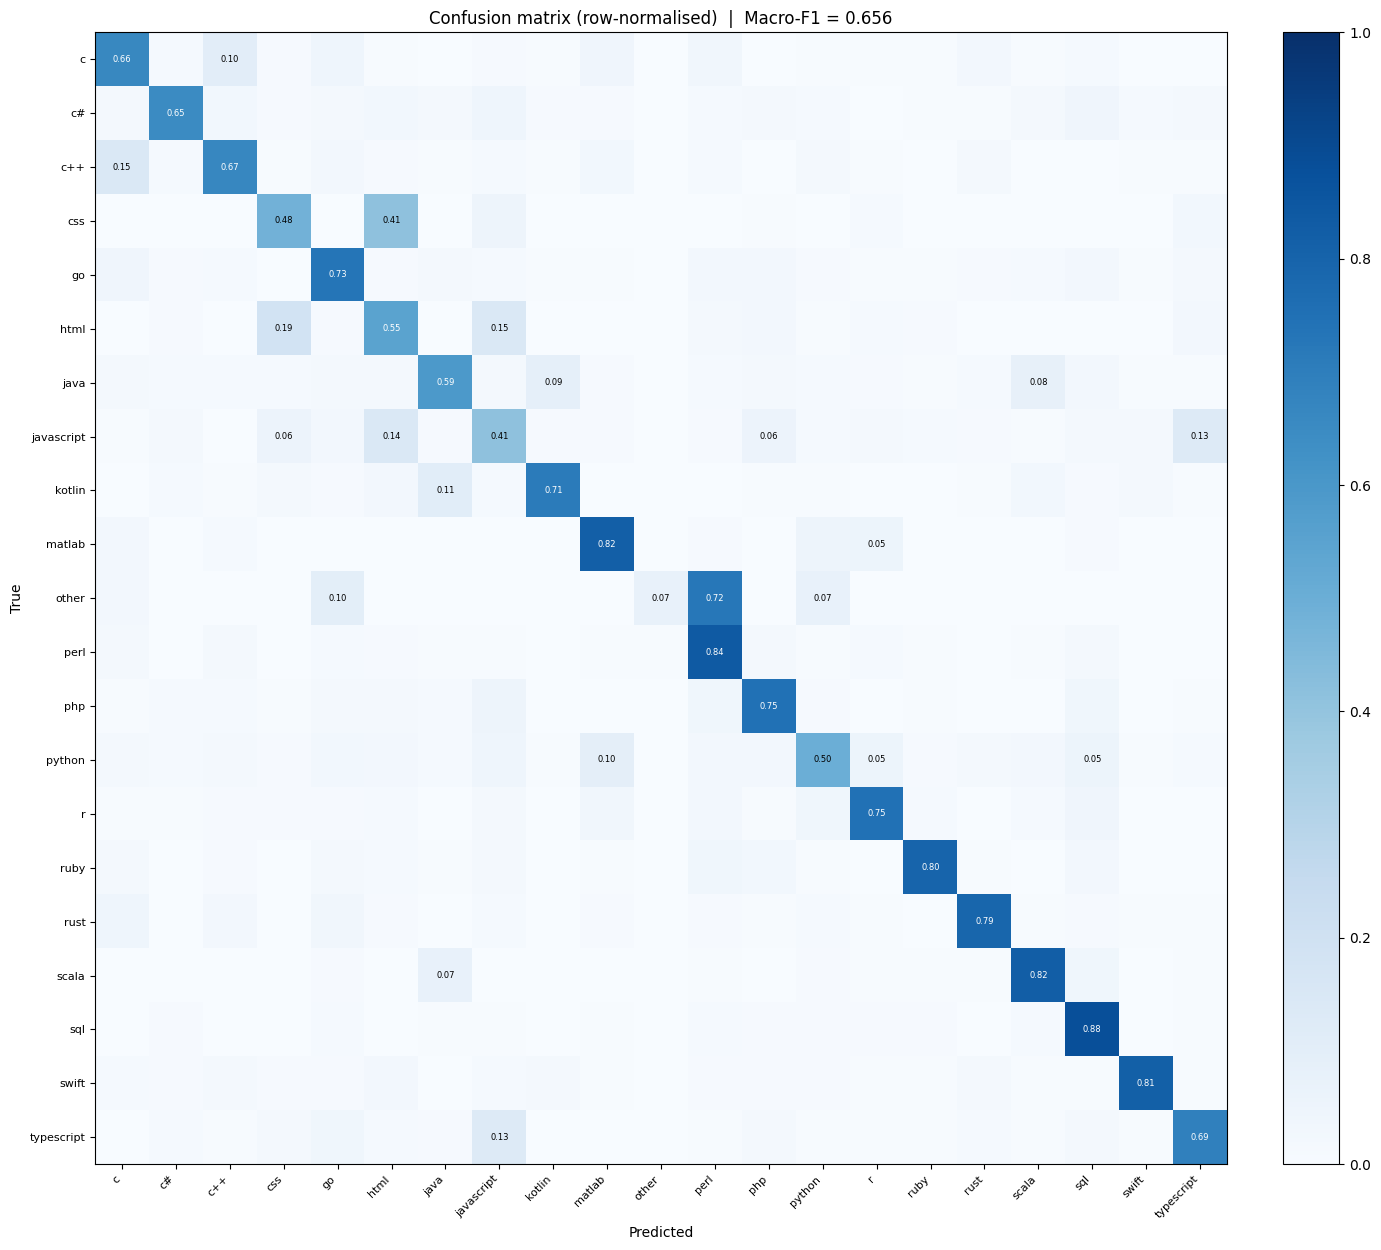

In [18]:
# Normalise rows (true class) so colours show recall, not raw counts
row_sums = cm.sum(axis=1, keepdims=True)
cm_norm  = np.where(row_sums > 0, cm / row_sums, 0.0)

n = len(labels)
fig, ax = plt.subplots(figsize=(max(8, n * 0.7), max(6, n * 0.6)))
im = ax.imshow(cm_norm, interpolation="nearest", cmap="Blues", vmin=0, vmax=1)
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

ax.set_xticks(range(n))
ax.set_yticks(range(n))
ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=8)
ax.set_yticklabels(labels, fontsize=8)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title(f"Confusion matrix (row-normalised)  |  Macro-F1 = {macro_f1:.3f}")

# Annotate cells with percentage (only if ≥ 5% to keep it readable)
for i in range(n):
    for j in range(n):
        val = cm_norm[i, j]
        if val >= 0.05:
            color = "white" if val > 0.5 else "black"
            ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                    fontsize=6, color=color)

plt.tight_layout()
plt.show()

---

## Bonus 6f – Explainability: Naive Bayes Token Scores

For each class and token, we compute:

`score(token, class) = log P(token | class) - average log P(token | other classes)`

This uses the learned log probabilities inside the custom Naive Bayes model, so no external explainability library is needed.

In [19]:
def indicative_tokens_df(model, id_to_token, top_n=10):
    log_cond = model.log_cond_
    n_classes = log_cond.shape[0]

    sum_all_classes = log_cond.sum(axis=0, keepdims=True)
    mean_other_classes = (sum_all_classes - log_cond) / (n_classes - 1)
    scores = log_cond - mean_other_classes

    rows = []
    for class_idx, class_name in enumerate(model.classes_):
        top_token_ids = np.argsort(scores[class_idx])[::-1][:top_n]
        for token_id in top_token_ids:
            rows.append({
                "class": class_name,
                "token": id_to_token.get(int(token_id), f"id:{token_id}"),
                "score": float(scores[class_idx, int(token_id)]),
            })
    return pd.DataFrame(rows, columns=["class", "token", "score"])


TOP_N = 10
indicative_df = indicative_tokens_df(model, id_to_token, top_n=TOP_N)
indicative_df

,class,token,score
0,c,scanf,5.387781
1,c,gcc,5.383091
2,c,printf,5.067368
3,c,malloc,5.037583
4,c,stm32,4.955353
...,...,...,...
205,typescript,prisma,5.414962
206,typescript,jest,5.411483
207,typescript,tsconfig,5.285312
208,typescript,eslint,5.240665
